In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns 

In [106]:
from sklearn.datasets import make_classification, make_moons, make_multilabel_classification
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import VotingClassifier, BaggingClassifier, ExtraTreesClassifier, RandomForestClassifier
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import classification_report, accuracy_score, roc_curve, auc
from sklearn.model_selection import cross_val_score
from sklearn.inspection import DecisionBoundaryDisplay
from matplotlib.colors import ListedColormap

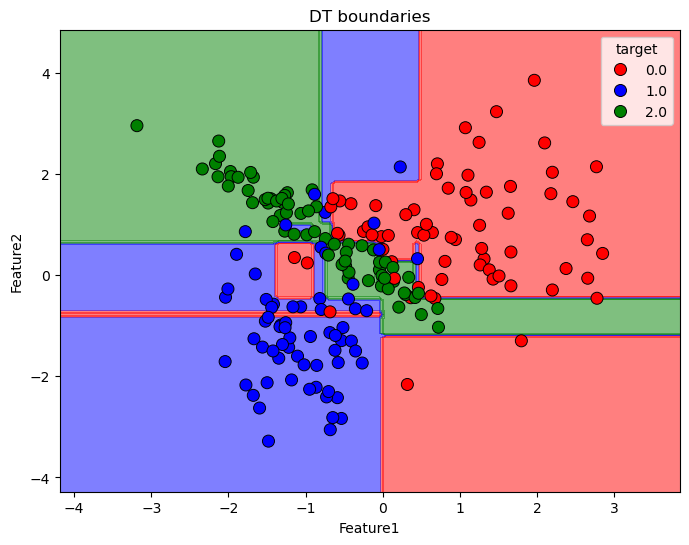

In [15]:
X, y = make_classification(
    n_samples=200,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_classes=3,
    n_clusters_per_class=1,
    random_state=26,
)

df = pd.DataFrame(
    data=np.column_stack((X, y)),
    columns=['Feature1', 'Feature2', 'target']
)

model = DecisionTreeClassifier()
model.fit(X, y)

plt.figure(figsize=(8,6))
display = DecisionBoundaryDisplay.from_estimator(
    model, X, 
    plot_method='contourf', response_method='predict',
    cmap=ListedColormap(['red', 'blue', 'green']),
    alpha=0.5,
    ax=plt.gca()
)
sns.scatterplot(
    data=df, x='Feature1', y='Feature2', hue='target', 
    palette=['red', 'blue', 'green'], s=75, edgecolor='k'
)
plt.title('DT boundaries')
plt.show()

# Voting Classifier

In [4]:
model_1 = KNeighborsClassifier(n_neighbors=5)
model_2 = Pipeline([
    ('poly', PolynomialFeatures(degree=2)),
    ('model_2', LogisticRegression())
])
model_3 = DecisionTreeClassifier(max_depth=5)

voting_model = VotingClassifier(
    estimators=[
        ('knn', model_1), ('logistic', model_2), ('dt', model_3)
    ],
    voting='soft',
    n_jobs=-1,
)

voting_model.fit(X, y)

,estimators,"[('knn', ...), ('logistic', ...), ...]"
,voting,'soft'
,weights,None
,n_jobs,-1
,flatten_transform,True
,verbose,False
,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2


In [5]:
voting_df = pd.DataFrame(
    data=classification_report(
        y, voting_model.predict(X),
        output_dict=True
    )
).T
voting_df

,precision,recall,f1-score,support
0,0.968254,0.897059,0.931298,68.000
1,0.950820,0.878788,0.913386,66.000
2,0.868421,1.000000,0.929577,66.000
accuracy,0.925000,0.925000,0.925000,0.925
macro avg,0.929165,0.925282,0.924754,200.000
weighted avg,0.929556,0.925000,0.924819,200.000


In [6]:
individual_df = pd.concat(
    {
        name: pd.DataFrame(
            classification_report(y, model.predict(X), output_dict=True, zero_division=0)
        ).T
        for name, model in voting_model.named_estimators_.items()
    },
    names=['model', 'class']
)
individual_df

precision    recall  f1-score  support
model    class                                               
knn      0              0.907692  0.867647  0.887218   68.000
         1              0.965517  0.848485  0.903226   66.000
         2              0.844156  0.984848  0.909091   66.000
         accuracy       0.900000  0.900000  0.900000    0.900
         macro avg      0.905788  0.900327  0.899845  200.000
         weighted avg   0.905808  0.900000  0.899719  200.000
logistic 0              0.948276  0.808824  0.873016   68.000
         1              0.964286  0.818182  0.885246   66.000
         2              0.767442  1.000000  0.868421   66.000
         accuracy       0.875000  0.875000  0.875000    0.875
         macro avg      0.893334  0.875668  0.875561  200.000
         weighted avg   0.893884  0.875000  0.875535  200.000
dt       0              0.984127  0.911765  0.946565   68.000
         1              0.938462  0.924242  0.931298   66.000
         2              0.888889  0.969697  0.927536   66.000
         accuracy       0.935000  0.935000  0.935000    0.935
         macro avg      0.937159  0.935235  0.935133  200.000
         weighted avg   0.937629  0.935000  0.935247  200.000

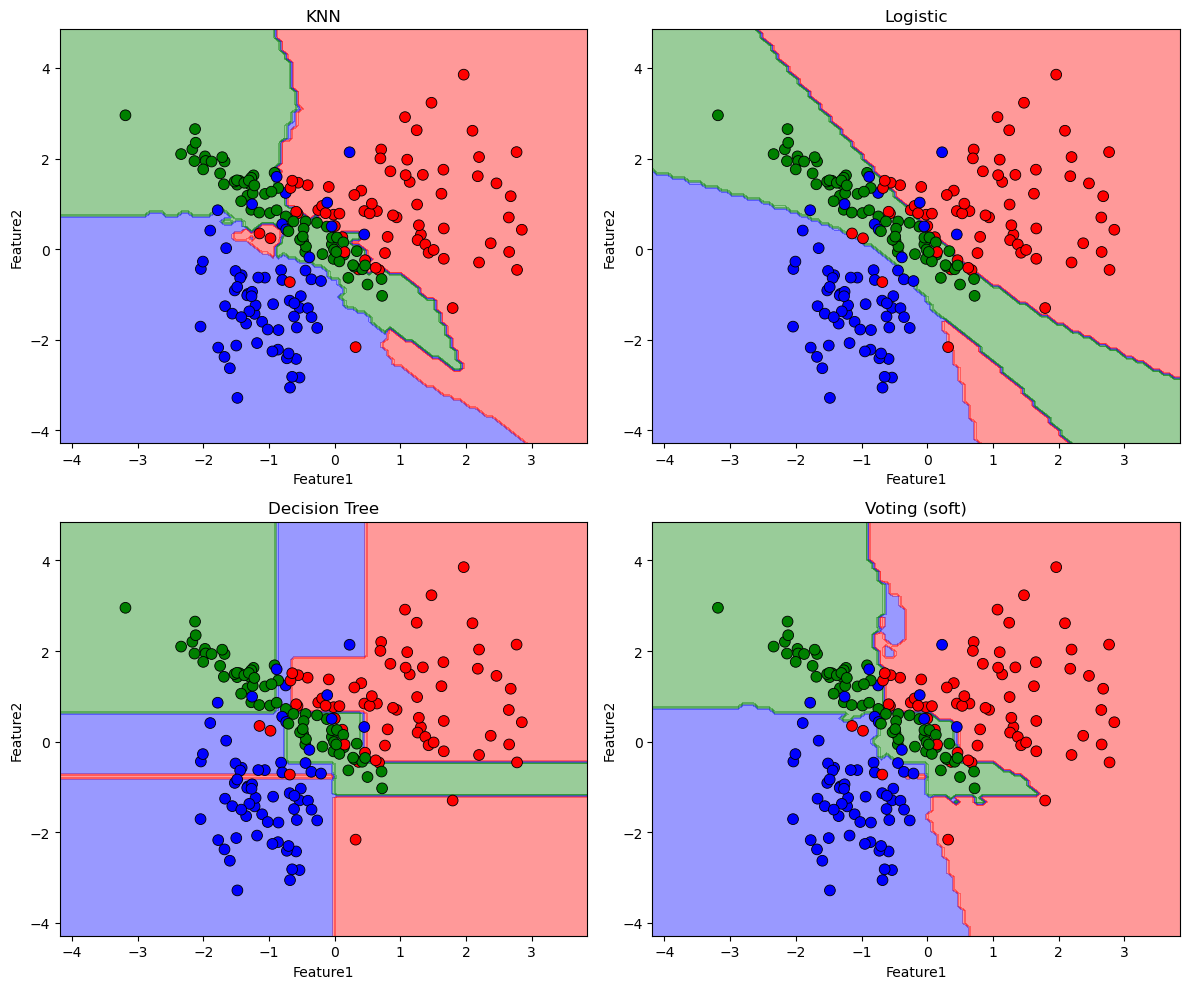

In [7]:
models = {
    'KNN': voting_model.named_estimators_['knn'],
    'Logistic': voting_model.named_estimators_['logistic'],
    'Decision Tree': voting_model.named_estimators_['dt'],
    'Voting (soft)': voting_model,
}

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, (name, model) in zip(axes, models.items()):
    DecisionBoundaryDisplay.from_estimator(
        model, X,
        plot_method='contourf',
        response_method='predict',
        cmap=ListedColormap(['red', 'blue', 'green']),
        alpha=0.4,
        ax=ax
    )
    sns.scatterplot(
        data=df, x='Feature1', y='Feature2', hue='target',
        palette=['red', 'blue', 'green'],
        s=60, edgecolor='k', ax=ax, legend=False
    )
    ax.set_title(name)
plt.tight_layout()
plt.show()

# Bagging

In [8]:
ensemble_bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(max_depth=6),
    n_estimators=100,
    bootstrap=True, 
    oob_score=True, 
    n_jobs=2,
    random_state=26
)
ensemble_bagging.fit(X, y)

,estimator,DecisionTreeC...r(max_depth=6)
,n_estimators,100
,max_samples,1.0
,max_features,1.0
,bootstrap,True
,bootstrap_features,False
,oob_score,True
,warm_start,False
,n_jobs,2
,random_state,26
,verbose,0


In [9]:
ensemble_bagging.oob_score_, ensemble_bagging.score(X, y)

(0.87, 0.96)

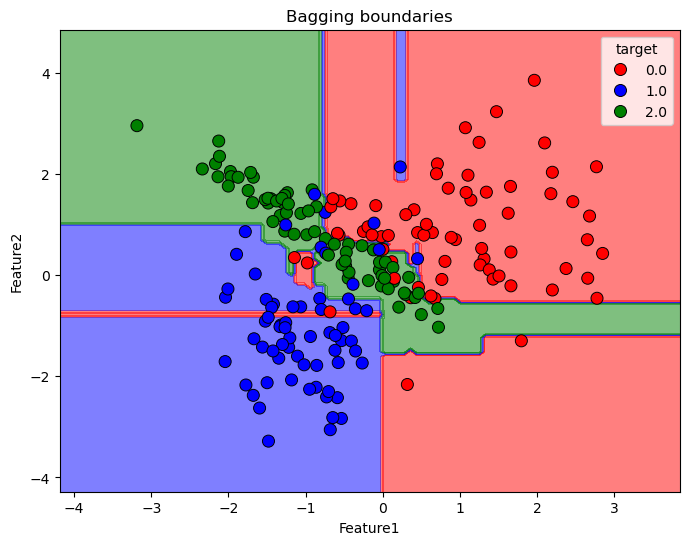

In [10]:
plt.figure(figsize=(8,6))
display = DecisionBoundaryDisplay.from_estimator(
    ensemble_bagging, X, 
    plot_method='contourf', response_method='predict',
    cmap=ListedColormap(['red', 'blue', 'green']),
    alpha=0.5,
    ax=plt.gca()
)
sns.scatterplot(
    data=df, x='Feature1', y='Feature2', hue='target', 
    palette=['red', 'blue', 'green'], s=75, edgecolor='k'
)
plt.title('Bagging boundaries')
plt.show()

In [11]:
pd.DataFrame(
    data=classification_report(
        y, ensemble_bagging.predict(X),
        output_dict=True
    )
).T

,precision,recall,f1-score,support
0,0.985075,0.970588,0.977778,68.00
1,1.000000,0.909091,0.952381,66.00
2,0.904110,1.000000,0.949640,66.00
accuracy,0.960000,0.960000,0.960000,0.96
macro avg,0.963061,0.959893,0.959933,200.00
weighted avg,0.963282,0.960000,0.960111,200.00


In [12]:
ensemble_bagging.oob_decision_function_.mean(axis=0)

array([0.33693177, 0.32312073, 0.33994749])

In [118]:
X, y = make_classification(
    n_samples=500,       
    n_features=30,       
    n_informative=10,     
    n_redundant=4,       
    n_classes=7,         
    random_state=26
)

feature_names = [f"feature_{i}" for i in range(30)]
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y
# df.head()

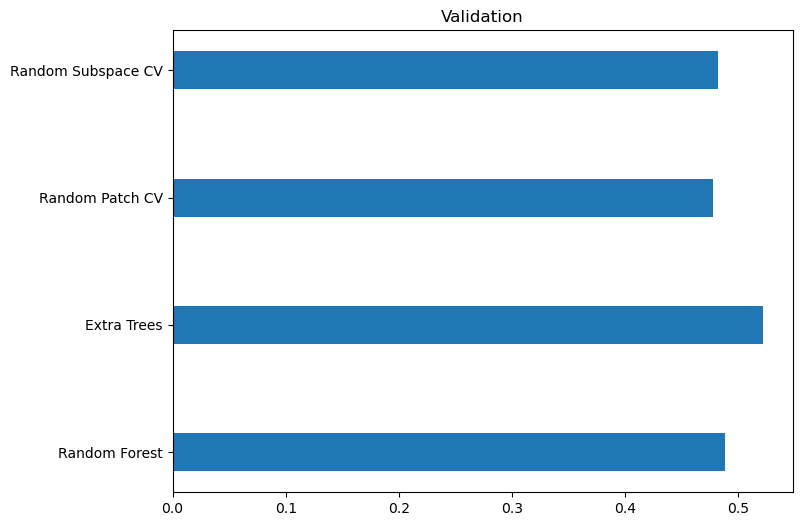

In [119]:
random_forest = RandomForestClassifier(
    n_estimators=50,
    criterion="entropy",
    random_state=26,
    bootstrap=True,
    oob_score=True,
    max_features=0.7,
    max_samples=1.0,
    n_jobs=3,
)

extra_trees = ExtraTreesClassifier(
    n_estimators=50,
    criterion="entropy",
    max_features=0.8,
    oob_score=True,
    bootstrap=True,
    random_state=26,
    n_jobs=3,
)

random_patch = BaggingClassifier(
    estimator=DecisionTreeClassifier(
        criterion="entropy",
        random_state=26,
    ),
    n_estimators=50,
    max_samples=0.7,
    max_features=0.7,
    bootstrap=True,
    bootstrap_features=False,
    oob_score=False,
    random_state=26,
    n_jobs=3,
)

random_subspace = BaggingClassifier(
    estimator=DecisionTreeClassifier(
        criterion="entropy",
        random_state=26,
    ),
    n_estimators=50,
    max_samples=1.0,
    max_features=0.7,
    bootstrap=False,
    bootstrap_features=False,
    oob_score=False,
    random_state=26,
    n_jobs=3,
)

random_forest.fit(df.drop(columns=['target']), y)
extra_trees.fit(df.drop(columns=['target']), y)
random_subspace.fit(df.drop(columns=['target']), y)
random_patch.fit(df.drop(columns=['target']), y)

plt.figure(figsize=(8,6))
plt.barh(
    ['Random Forest', 'Extra Trees', 'Random Patch CV', 'Random Subspace CV'],
    width = [
        cross_val_score(
            random_forest, X, y, 
            scoring='accuracy', 
            cv=5, 
            n_jobs=3, 
        ).mean(),
        cross_val_score(
            extra_trees, X, y, 
            scoring='accuracy', 
            cv=5, 
            n_jobs=3, 
        ).mean(),
        cross_val_score(
            random_patch, X, y, 
            scoring='accuracy', 
            cv=5, 
            n_jobs=3, 
        ).mean(),
        cross_val_score(
            random_subspace, X, y, 
            scoring='accuracy', 
            cv=5, 
            n_jobs=3, 
        ).mean()
    ],
    height=0.3,
)
plt.title('Validation')
plt.show()

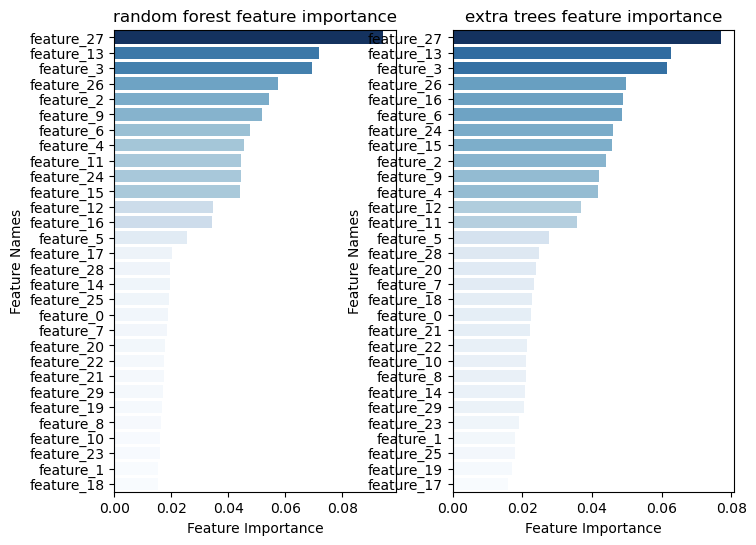

In [120]:
models = {
    'random forest': random_forest,
    # 'random patch': random_patch, 
    # 'random subspace': random_subspace,
    'extra trees': extra_trees
}
fig, ax = plt.subplots(1, 2, figsize=(8,6))
ax = ax.flatten()
for i, (name, model) in enumerate(models.items()):
    feature_df = pd.DataFrame(
        data={
            'Feature Names': df.drop(columns='target').columns,
            'Feature Importance': model.feature_importances_
        }
    )
    feature_df = feature_df[feature_df['Feature Importance'] > 0.01].sort_values(by='Feature Importance', ascending=False)
    sns.barplot(
        data=feature_df, x='Feature Importance', y='Feature Names',
        hue='Feature Importance', ax=ax[i], palette='Blues', legend=False
    )
    ax[i].set_title(f'{name} feature importance')
plt.show()

In [121]:
models = {
    'random forest': random_forest,
    'random patch': random_patch, 
    'random subspace': random_subspace,
    'extra trees': extra_trees
}
for i,(name, model) in enumerate(models.items()):
    print(name)

random forest
random patch
random subspace
extra trees


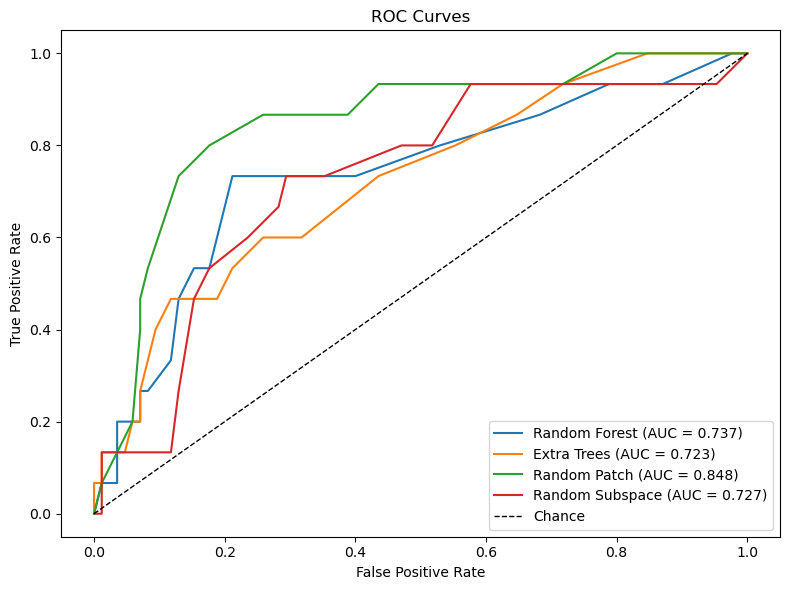

In [129]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc

# ---- split once ----
X = df.drop(columns='target')
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=26
)

models = {
    'Random Forest':   random_forest,
    'Extra Trees':     extra_trees,
    'Random Patch':    random_patch,
    'Random Subspace': random_subspace,
}

plt.figure(figsize=(8, 6))

for name, model in models.items():
    model.fit(X_train, y_train)

    # scores, NOT hard labels
    y_score = model.predict_proba(X_test)[:, 2]

    fpr, tpr, _ = roc_curve(y_test, y_score, pos_label=2)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()